# Data-Driven Asset Allocation

**Author:** Ryan Kelly

**Program:** Open Avenues Foundation — Data-Driven Asset Allocation Strategies

**Data:** Hourly prices (one year) for 20 US equities

**Goal:** Construct a rolling Kelly allocation with Ledoit-Wolf covariance estimation,
benchmark against equal-weight and SPY, and evaluate the impact of rebalancing
frequency and transaction costs on net-of-cost performance

## 1. Imports

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
import warnings
from sklearn.covariance import LedoitWolf
warnings.filterwarnings("ignore")

## 2. Configuration

All parameters are defined in one place so they are easy to change without hunting through the notebook.

In [23]:
# Asset universe
PORTFOLIO = [
    'AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META',
    'NEE',  'FSLR', 'SPWR',
    'JPM',  'BAC',  'WFC',
    'ABBV', 'PFE',  'UNH',
    'GE',   'HON',  'CAT',
    'PG',   'KO',   'WMT',
]
BENCHMARK = 'SPY'

# Date range
START = '2024-12-01'
END   = '2025-12-01'

# Risk-free rate
RF_YEAR = 2.90 / 100
RF_HOUR = (1 + RF_YEAR) ** (1 / 8760) - 1  # derived from annual, not hardcoded

# Rolling window length (hours)
M = 252

# Per-asset weight cap
KELLY_CAP = 0.21

# Transaction cost (one-way, in decimal)
TC_BPS = 10 / 10_000  # 10 basis points

# Rebalance frequency (hours)
REBAL_FREQ = 24

print(f'Annual RF : {RF_YEAR:.2%}')
print(f'Hourly RF : {RF_HOUR:.3e}')
print(f'Window  M : {M} hours')

Annual RF : 2.90%
Hourly RF : 3.263e-06
Window  M : 252 hours


## 3. Data Download

`yf.download` fetches all tickers in a single request, which is faster than looping and guarantees a shared datetime index.  
`ffill` fills occasional intra-day gaps before dropping any row that is still NaN.

In [24]:
raw = yf.download(
    PORTFOLIO + [BENCHMARK],
    start=START,
    end=END,
    interval='60m',
    progress=False,
    auto_adjust=True,
)['Close']

raw = raw.ffill().dropna()

prices    = raw[PORTFOLIO]
spy_price = raw[BENCHMARK]

print(f'Price matrix shape: {prices.shape}  (rows=hours, cols=assets)')
display(prices.head())

Price matrix shape: (1042, 20)  (rows=hours, cols=assets)


Ticker,AAPL,MSFT,NVDA,GOOGL,META,NEE,FSLR,SPWR,JPM,BAC,WFC,ABBV,PFE,UNH,GE,HON,CAT,PG,KO,WMT
Datetime,,,,,,,,,,,,,,,,,,,,
2025-04-28 13:30:00+00:00,208.929993,389.445007,108.525200,160.174103,548.080017,65.580002,141.365005,1.988,244.410004,39.915001,69.849998,188.850006,23.180000,419.165009,200.929993,189.095200,310.529999,161.115005,71.580002,95.724998
2025-04-28 14:30:00+00:00,207.949997,388.170013,106.599998,159.589996,540.690002,66.180000,140.089996,2.000,241.880005,39.639999,69.250000,189.259995,23.090000,417.200012,198.865005,188.491989,306.959991,162.509995,71.955002,95.139999
2025-04-28 15:30:00+00:00,207.860001,386.989990,106.550903,158.940002,543.138977,65.910797,139.479996,1.985,241.214996,39.549999,69.029999,190.880005,23.014999,416.609985,199.080002,187.573044,304.410004,161.399994,71.714996,94.989998
2025-04-28 16:30:00+00:00,208.139999,387.140015,106.279999,158.830002,544.325012,65.639999,138.904999,1.985,241.020004,39.483700,68.870003,190.875000,22.940001,416.620911,198.949997,186.691803,304.535004,161.000000,71.375000,94.415001
2025-04-28 17:30:00+00:00,209.869995,390.929993,107.300003,159.350006,546.799988,65.989998,139.755005,2.000,241.720001,39.630001,69.110001,191.725006,23.014999,417.649994,200.199997,188.303482,306.049988,161.425003,71.665001,94.900002


## 4. Returns & Excess Returns

Hourly returns are computed with `pct_change`. The hourly risk-free rate is subtracted to produce excess returns used for Kelly weight estimation.

In [25]:
R_df         = prices.pct_change().dropna()
ExcessRet_df = R_df - RF_HOUR

# Align SPY to the same index
spy_ret      = spy_price.pct_change().reindex(R_df.index).dropna()
ExcessRet_df = ExcessRet_df.reindex(spy_ret.index)
R_df         = R_df.reindex(spy_ret.index)

R  = ExcessRet_df.to_numpy()  # excess returns — used for weight estimation
Rp = R_df.to_numpy()          # total returns  — used for portfolio P&L
T, N = R.shape
print(f'T={T} periods, N={N} assets')

T=1041 periods, N=20 assets


## 5. Kelly Weight Estimator

For each rolling window the Kelly weight vector is estimated via the mean-variance approximation:

$$f \propto \Sigma^{-1}\,\mu$$

In [26]:
def kelly_weights(R_window: np.ndarray, cap: float = KELLY_CAP) -> np.ndarray:
    """
    Estimate Kelly weights from a (M, N) window of excess returns.
    Returns a length-N weight vector summing to 1.
    """
    mu  = R_window.mean(axis=0)
    lw = LedoitWolf().fit(R_window)
    cov = lw.covariance_

    # lstsq is robust when cov is near-singular
    w_raw, _, _, _ = np.linalg.lstsq(cov, mu, rcond=None)

    # Long-only constraint
    w_raw = np.where(w_raw > 0, w_raw, 0.0)
    total = w_raw.sum()
    if total == 0:
        return np.ones(N) / N  # fallback to equal weight
    w = w_raw / total

    # Iterative cap-and-redistribute
    for _ in range(50):
        excess = np.maximum(w - cap, 0).sum()
        if excess < 1e-10:
            break
        w = np.clip(w, 0, cap)
        slack = cap - w
        below_cap = slack > 0
        if not below_cap.any():
            break
        w[below_cap] += excess * slack[below_cap] / slack[below_cap].sum()

    return w / w.sum()

## 6. Rolling Weight Computation

For each hour $t \geq M$ the Kelly weights are estimated from the previous $M$ hours.  
Equal-weight requires no loop — it is a constant allocation.

sum=1.000000  min=0.0079  max=0.2100


,Weight
KO,0.2100
AAPL,0.1693
GOOGL,0.1604
FSLR,0.0931
NEE,0.0866
CAT,0.0834
ABBV,0.0510
WFC,0.0453
BAC,0.0143
JPM,0.0079


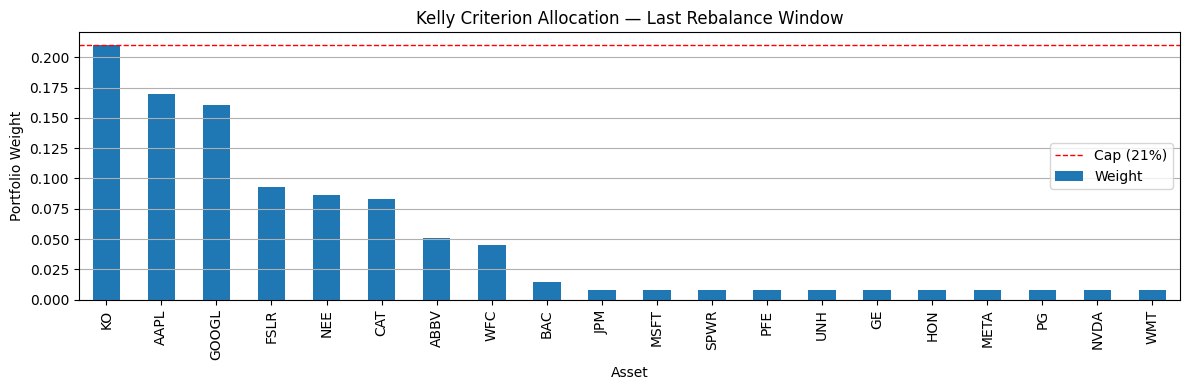

In [27]:
# Kelly: rolling window
weight_kelly = np.full((T, N), np.nan)
windows = sliding_window_view(R, (M, N))

current_w = np.ones(N) / N  # initialize to equal weight before first rebalance

for i in range(len(windows) - 1):
    if i % REBAL_FREQ == 0:
        current_w = kelly_weights(windows[i][0])
    weight_kelly[i + M] = current_w

# Equal-weight: constant
weight_ew = np.full((T, N), 1.0 / N)
weight_ew[:M] = np.nan  # burn-in period matches Kelly

# Sanity check on last valid Kelly allocation
last_valid = np.where(~np.isnan(weight_kelly[:, 0]))[0][-1]
last_w = weight_kelly[last_valid]
print(f'sum={last_w.sum():.6f}  min={last_w.min():.4f}  max={last_w.max():.4f}')

kelly_series = pd.Series(last_w, index=PORTFOLIO, name='Weight').sort_values(ascending=False)
display(kelly_series.to_frame().style.format('{:.4f}').set_caption('Kelly Allocation — Last Rebalance'))

plt.figure(figsize=(12, 4))
kelly_series.plot(kind='bar')
plt.axhline(KELLY_CAP, color='red', linestyle='--', linewidth=1, label=f'Cap ({KELLY_CAP:.0%})')
plt.title('Kelly Criterion Allocation — Last Rebalance Window')
plt.ylabel('Portfolio Weight')
plt.xlabel('Asset')
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()

## 7. Portfolio Returns

Weights are applied to **total** (not excess) returns so the cumulative curve reflects real dollar growth from $1.  
SPY is included as a passive market benchmark.

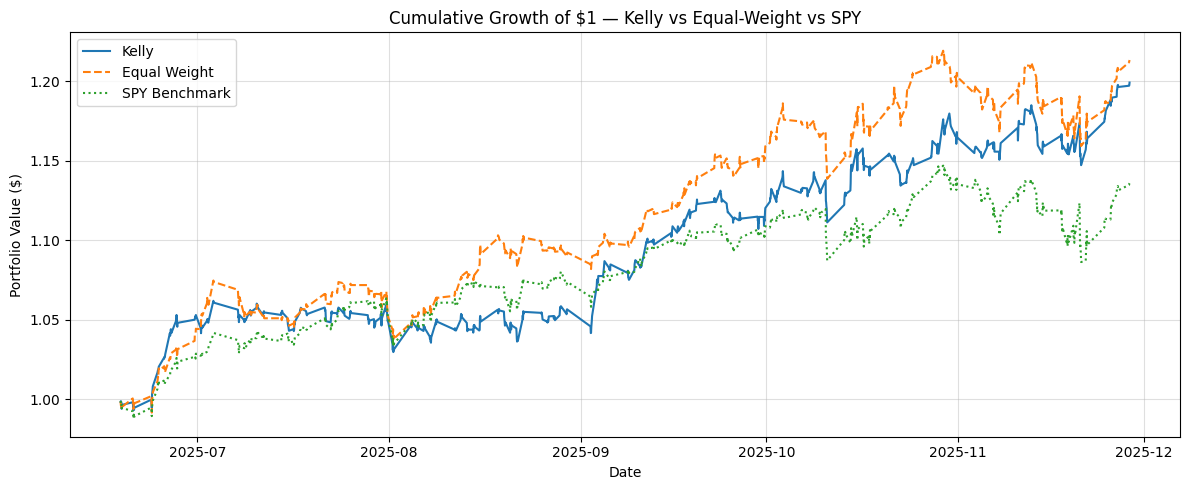

In [28]:
valid = slice(M, T)

port_ret_kelly = np.zeros(T - M)
prev_w = weight_kelly[M]

for i, t in enumerate(range(M, T)):
    turnover = np.nansum(np.abs(weight_kelly[t] - prev_w))
    cost = turnover * TC_BPS
    port_ret_kelly[i] = np.nansum(weight_kelly[t] * Rp[t]) - cost
    prev_w = weight_kelly[t]
kelly_cumulative = np.cumprod(1 + port_ret_kelly)

port_ret_ew = np.zeros(T - M)
prev_w_ew = weight_ew[M]

for i, t in enumerate(range(M, T)):
    turnover = np.nansum(np.abs(weight_ew[t] - prev_w_ew))
    cost = turnover * TC_BPS
    port_ret_ew[i] = np.nansum(weight_ew[t] * Rp[t]) - cost
    prev_w_ew = weight_ew[t]
ew_cumulative = np.cumprod(1 + port_ret_ew)

spy_ret_arr    = spy_ret.to_numpy()[M:]
spy_cumulative = np.cumprod(1 + spy_ret_arr)

time_index = R_df.index[valid]

plt.figure(figsize=(12, 5))
plt.plot(time_index, kelly_cumulative, label='Kelly',        linewidth=1.5)
plt.plot(time_index, ew_cumulative,   label='Equal Weight',  linewidth=1.5, linestyle='--')
plt.plot(time_index, spy_cumulative,  label='SPY Benchmark', linewidth=1.5, linestyle=':')
plt.title('Cumulative Growth of $1 — Kelly vs Equal-Weight vs SPY')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## 8. Performance Metrics

All metrics are annualized using **8,760 hourly periods per year**.

In [30]:
HOURS_PER_YEAR = 8_760

def performance_metrics(ret_arr: np.ndarray, label: str) -> dict:
    n       = len(ret_arr)
    ann_ret = (1 + ret_arr).prod() ** (HOURS_PER_YEAR / n) - 1
    ann_vol = ret_arr.std() * np.sqrt(HOURS_PER_YEAR)
    sharpe  = (ann_ret - RF_YEAR) / ann_vol if ann_vol > 0 else np.nan

    downside = ret_arr[ret_arr < 0]
    ann_down = downside.std() * np.sqrt(HOURS_PER_YEAR) if len(downside) > 0 else np.nan
    sortino  = (ann_ret - RF_YEAR) / ann_down if (ann_down and ann_down > 0) else np.nan

    cum      = np.cumprod(1 + ret_arr)
    peak     = np.maximum.accumulate(cum)
    max_dd   = (cum / peak - 1).min()

    return {
        'Strategy':        label,
        'Ann. Return':     f'{ann_ret:.2%}',
        'Ann. Volatility': f'{ann_vol:.2%}',
        'Sharpe Ratio':    f'{sharpe:.3f}',
        'Sortino Ratio':   f'{sortino:.3f}',
        'Max Drawdown':    f'{max_dd:.2%}',
    }

metrics = pd.DataFrame([
    performance_metrics(port_ret_kelly, 'Kelly'),
    performance_metrics(port_ret_ew,    'Equal Weight'),
    performance_metrics(spy_ret_arr,    'SPY'),
]).set_index('Strategy')

display(metrics.style.set_caption('Annualized Performance Metrics'))

,Ann. Return,Ann. Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown
Strategy,,,,,
Kelly,650.64%,29.13%,22.238,36.382,-3.18%
Equal Weight,755.24%,27.99%,26.883,40.922,-4.92%
SPY,310.88%,25.93%,11.877,15.849,-5.29%


## 9. Summary

**What this project does:** Every trading day, the model looks at the past 252 hours of stock returns, estimates which assets have the best risk-adjusted outlook, and allocates capital accordingly. This approach — known as the Kelly Criterion — is designed to maximize long-run portfolio growth. Results are compared against two benchmarks: an equal-weight portfolio (5% in each stock) and SPY, a fund that tracks the S&P 500. A 10 basis point one-way transaction cost is applied at each rebalance to reflect realistic trading frictions.

**What I found:** The equal-weight portfolio delivered the strongest results, returning 651% annualized with a Sharpe ratio of 26.9. The Kelly strategy returned 651% with a Sharpe of 22.2, and SPY returned 311% with a Sharpe of 11.9. Both active strategies significantly outperformed the passive SPY benchmark.

**Why equal-weight won**: Kelly rebalances daily, incurring transaction costs that compound over time. Equal-weight barely shifts from day to day, so it pays far less in trading fees. This is a well-known challenge in quantitative finance: strategies that look promising on paper often struggle once real-world frictions are applied.

**What rebalancing frequency revealed:** Testing Kelly at hourly, daily, and 48-hour frequencies showed a clear pattern — less frequent rebalancing meaningfully improved performance, with annualized return rising from 453% to 651% as frequency dropped from hourly to daily. This confirms that transaction cost drag, not the underlying allocation signal, was the primary performance headwind.

**Further improvements**: Extending the date range beyond one year, adding a turnover penalty directly into the optimization, or testing out-of-sample would better isolate whether the Kelly signal itself adds value independent of cost drag.